# DNA Adaptive Tokenizer Playground

Use this after copying a trained checkpoint folder locally. The notebook loads `best.pt`, reconstructs DNA, inspects token usage, and lets you poke the latent space with interpolation and perturbations.

In [70]:
from pathlib import Path
import sys
import random
import time
import torch
import matplotlib.pyplot as plt

print('Starting imports...')
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('mps available:', torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False)

# Change this if the notebook is not run from the repo root.
REPO = Path.cwd()
if not (REPO / 'scripts' / 'dna_adaptive_tokenizer_autoencoder.py').exists():
    REPO = Path('..').resolve()
print('repo:', REPO)

sys.path.insert(0, str(REPO))

from scripts.dna_adaptive_tokenizer_autoencoder import (
    build_model,
    sequence_to_tensor,
    tensor_to_sequence,
    generate_controlled_sequence,
)

def pick_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = pick_device()
print('selected device:', device)
print('Imports done.')


Starting imports...
torch: 2.10.0
cuda available: False
mps available: True
repo: /Users/ogw/Documents/GitHub/Central_Dogma_AI
selected device: mps
Imports done.


## Load checkpoint

Set `CKPT` to your local copied checkpoint. Use `best.pt` first; later compare against individual `best_step_*.pt` files.

In [71]:
CKPT = REPO / 'checkpoints' / 'dna_adaptive_tokenizer_best.pt'

# Alternative, if you copied the whole checkpoint folder instead of renaming best.pt:
# CKPT = REPO / 'checkpoints' / 'dna_adaptive_tokenizer_long_only_len100_slots32_tokcost002' / 'best.pt'

print('checkpoint path:', CKPT.resolve())
print('exists:', CKPT.exists())
if not CKPT.exists():
    print('repo checkpoints dir:', (REPO / 'checkpoints').resolve())
    if (REPO / 'checkpoints').exists():
        print('available checkpoint-ish files:')
        for candidate in sorted((REPO / 'checkpoints').glob('**/*.pt'))[:20]:
            print('  ', candidate.relative_to(REPO))
    raise FileNotFoundError(f'Checkpoint not found: {CKPT.resolve()}')

print('Loading checkpoint...')
t0 = time.perf_counter()
checkpoint = torch.load(CKPT, map_location=device)
print(f'Loaded checkpoint in {time.perf_counter() - t0:.2f}s')

args_dict = checkpoint['args']

class Args:
    pass

args = Args()
for key, value in args_dict.items():
    setattr(args, key, value)

print('checkpoint step:', checkpoint.get('step'))
print('validation_loss:', checkpoint.get('validation_loss'))
print('model args:', {k: getattr(args, k) for k in ['seq_len', 'max_tokens', 'latent_dim', 'max_slots_per_token']})

print('Building model...')
t0 = time.perf_counter()
model = build_model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model ready in {time.perf_counter() - t0:.2f}s')
print('parameter count:', sum(p.numel() for p in model.parameters()))


checkpoint path: /Users/ogw/Documents/GitHub/Central_Dogma_AI/checkpoints/dna_adaptive_tokenizer_best.pt
exists: True
Loading checkpoint...
Loaded checkpoint in 0.05s
checkpoint step: 99999
validation_loss: 0.13056272268295288
model args: {'seq_len': 100, 'max_tokens': 24, 'latent_dim': 128, 'max_slots_per_token': 32}
Building model...
Model ready in 0.02s
parameter count: 337670


## Helpers

In [72]:
DNA = 'ACGT'

# Keep notebook operations small by default. Increase later if things are responsive.
DEFAULT_SEQ_LEN = min(args.seq_len, 100)
print('DEFAULT_SEQ_LEN:', DEFAULT_SEQ_LEN)

def make_batch_from_strings(seqs):
    max_len = args.seq_len
    print(f'make_batch_from_strings: {len(seqs)} seqs, model max_len={max_len}')
    target = torch.zeros(len(seqs), max_len, dtype=torch.long)
    mask = torch.zeros(len(seqs), max_len, dtype=torch.float32)
    lengths = []
    for i, seq in enumerate(seqs):
        seq = seq.upper()[:max_len]
        lengths.append(len(seq))
        t = sequence_to_tensor(seq)
        target[i, :len(seq)] = t
        mask[i, :len(seq)] = 1.0
    print('lengths:', lengths)
    return target.to(device), mask.to(device), torch.tensor(lengths, device=device)

@torch.no_grad()
def encode_decode(seqs, label='batch'):
    print(f'encode_decode {label}: start')
    t0 = time.perf_counter()
    target, mask, lengths = make_batch_from_strings(seqs)
    print('running model forward...')
    t1 = time.perf_counter()
    out = model(target, mask)
    print(f'forward done in {time.perf_counter() - t1:.2f}s')
    pred = out['soft_dna'].argmax(dim=-1)
    decoded = [tensor_to_sequence(pred[i, :int(lengths[i].item())]) for i in range(len(seqs))]
    token_count = out['token_usage'].sum(dim=1).detach().cpu()
    print(f'encode_decode {label}: total {time.perf_counter() - t0:.2f}s')
    print('token_count:', [round(float(x), 2) for x in token_count])
    return out, decoded, token_count, lengths.detach().cpu()

def hamming_frac(a, b):
    n = min(len(a), len(b))
    if n == 0:
        return 0.0
    return sum(x != y for x, y in zip(a[:n], b[:n])) / n

def plot_token_probs(out, idx=0, title='token probabilities'):
    print('plot_token_probs start')
    probs = out['token_prob'][idx].detach().cpu()
    plt.figure(figsize=(12, 2.5))
    plt.plot(probs)
    plt.ylim(-0.02, 1.02)
    plt.title(title)
    plt.xlabel('base position')
    plt.ylabel('open-token prob')
    plt.show()
    print('plot_token_probs done')

def plot_emit_lengths(out, idx=0, title='emitted lengths'):
    print('plot_emit_lengths start')
    lengths = out['lengths'][idx].detach().cpu()
    plt.figure(figsize=(8, 2.5))
    plt.bar(range(len(lengths)), lengths)
    plt.title(title)
    plt.xlabel('latent token slot')
    plt.ylabel('emitted bases')
    plt.show()
    print('plot_emit_lengths done')


DEFAULT_SEQ_LEN: 100


## Interactive token editing

Paste a DNA sequence, encode it once into latent tokens, then edit token values and decode repeatedly. The colored rows compare each edited decode against the original decoded sequence.


In [73]:
from IPython.display import HTML, display

BASE_COLORS = {
    'A': '#2e7d32',
    'C': '#1565c0',
    'G': '#ef6c00',
    'T': '#ad1457',
    'N': '#616161',
}

# Paste your sequence here, then run this cell.
USER_DNA = 'ACGTACGTACGTACGTACGTACGTACGTACGTACGTACGT'
TOKEN_STATE = {}


def _html_escape(text):
    return str(text).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')


def align_pair(ref, seq, match=2, mismatch=-1, gap=-2):
    """Tiny global aligner for short notebook DNA strings."""
    n, m = len(ref), len(seq)
    score = [[0] * (m + 1) for _ in range(n + 1)]
    trace = [[None] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        score[i][0] = score[i - 1][0] + gap
        trace[i][0] = 'up'
    for j in range(1, m + 1):
        score[0][j] = score[0][j - 1] + gap
        trace[0][j] = 'left'
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = score[i - 1][j - 1] + (match if ref[i - 1] == seq[j - 1] else mismatch)
            up = score[i - 1][j] + gap
            left = score[i][j - 1] + gap
            best = max(diag, up, left)
            score[i][j] = best
            trace[i][j] = 'diag' if best == diag else ('up' if best == up else 'left')
    i, j = n, m
    ar, aq = [], []
    while i > 0 or j > 0:
        step = trace[i][j]
        if step == 'diag':
            ar.append(ref[i - 1]); aq.append(seq[j - 1]); i -= 1; j -= 1
        elif step == 'up':
            ar.append(ref[i - 1]); aq.append('-'); i -= 1
        else:
            ar.append('-'); aq.append(seq[j - 1]); j -= 1
    return ''.join(reversed(ar)), ''.join(reversed(aq))


def aligned_similarity(ref, seq):
    ar, aq = align_pair(ref, seq)
    aligned = max(1, len(ar))
    matches = sum(r == q for r, q in zip(ar, aq) if r != '-' and q != '-')
    edits = sum(r != q for r, q in zip(ar, aq))
    return {
        'aligned_ref': ar,
        'aligned_seq': aq,
        'matches': matches,
        'edits': edits,
        'similarity': matches / aligned,
        'edit_frac': edits / aligned,
    }


def dna_span(seq, ref=None, max_len=260, aligned=False):
    pieces = []
    shown = seq[:max_len]
    for i, base in enumerate(shown):
        b = base.upper()
        fg = BASE_COLORS.get(b, '#444') if b != '-' else '#999'
        mismatch = ref is not None and (i >= len(ref) or b != ref[i].upper())
        is_gap = b == '-'
        bg = '#ffcdd2' if is_gap else ('#ffe082' if mismatch else 'transparent')
        border = 'border-bottom: 2px solid #d32f2f;' if mismatch else ''
        char = '&middot;' if is_gap else _html_escape(b)
        pieces.append(
            f"<span style='color:{fg};background:{bg};{border};padding:0 1px'>{char}</span>"
        )
    if len(seq) > max_len:
        pieces.append("<span style='color:#777'>...</span>")
    return ''.join(pieces)


def show_dna_rows(rows, ref=None, max_len=260, align=True):
    html = [
        "<div style='font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace; font-size: 13px; line-height: 1.7'>",
        "<div style='margin-bottom:6px;color:#555'>A/C/G/T are color-coded; yellow marks aligned substitutions, red dots are alignment gaps/indels.</div>",
    ]
    for label, seq in rows:
        display_seq = seq
        display_ref = ref
        subtitle = f'{len(seq)} bp'
        if align and ref is not None and seq != ref:
            aln = aligned_similarity(ref, seq)
            display_ref = aln['aligned_ref']
            display_seq = aln['aligned_seq']
            subtitle = f"{len(seq)} bp; align_sim {aln['similarity']:.3f}; edit_frac {aln['edit_frac']:.3f}"
        html.append(
            "<div style='display:grid;grid-template-columns:220px 1fr;gap:10px;align-items:start'>"
            f"<div style='color:#555'>{_html_escape(label)} ({subtitle})</div>"
            f"<div>{dna_span(display_seq, ref=display_ref, max_len=max_len)}</div>"
            "</div>"
        )
    html.append('</div>')
    display(HTML(''.join(html)))

def _make_single(seq):
    seq = ''.join(ch for ch in seq.upper() if ch in DNA)
    if not seq:
        raise ValueError('USER_DNA has no A/C/G/T bases.')
    if len(seq) > args.seq_len:
        print(f'truncating input from {len(seq)} to model seq_len={args.seq_len}')
        seq = seq[:args.seq_len]
    target = torch.zeros(1, args.seq_len, dtype=torch.long)
    mask = torch.zeros(1, args.seq_len, dtype=torch.float32)
    target[0, :len(seq)] = sequence_to_tensor(seq)
    mask[0, :len(seq)] = 1.0
    return seq, target.to(device), mask.to(device), torch.tensor([len(seq)], device=device)


@torch.no_grad()
def encode_user_dna(seq=None):
    seq = USER_DNA if seq is None else seq
    clean_seq, target, mask, lengths = _make_single(seq)
    print(f'Encoding one sequence: {len(clean_seq)} bp on {device}')
    t0 = time.perf_counter()
    tokenized = model.tokenize(target, mask)
    rendered = model.decode(tokenized['latents'], tokenized['token_usage'], args.seq_len)
    elapsed = time.perf_counter() - t0

    decoded_input_len = tensor_to_sequence(rendered['soft_dna'].argmax(dim=-1)[0, :int(lengths[0].item())])
    baseline_len = int(round(float(rendered['total_len'][0].item())))
    baseline_len = max(1, min(args.seq_len, baseline_len))
    pred = rendered['soft_dna'].argmax(dim=-1)[0, :baseline_len]
    decoded = tensor_to_sequence(pred)
    token_usage = tokenized['token_usage'][0].detach().cpu()
    lengths_out = rendered['lengths'][0].detach().cpu()
    latents = tokenized['latents'][0].detach().clone()

    TOKEN_STATE.clear()
    TOKEN_STATE.update({
        'input': clean_seq,
        'target': target.detach(),
        'mask': mask.detach(),
        'lengths': lengths.detach(),
        'latents': latents,
        'usage': tokenized['token_usage'][0].detach().clone(),
        'original_decoded': decoded,
        'decoded_input_len': decoded_input_len,
        'baseline_len': baseline_len,
    })

    print(f'Encoded+decoded in {elapsed:.2f}s')
    print(f'token mass: {float(token_usage.sum()):.2f}; rendered length: {float(rendered["total_len"][0].item()):.1f}')
    print('Token table: idx | usage | emit_len | latent_norm | first 8 latent dims')
    z_cpu = latents.detach().cpu()
    for i in range(args.max_tokens):
        if float(token_usage[i]) < 0.02 and i > float(token_usage.sum()) + 4:
            continue
        first_dims = ' '.join(f'{x:+.2f}' for x in z_cpu[i, :8].tolist())
        print(f'{i:02d} | {float(token_usage[i]):.3f} | {float(lengths_out[i]):5.2f} | {float(z_cpu[i].norm()):5.2f} | {first_dims}')

    show_dna_rows([('input', clean_seq), ('decoded input length', decoded_input_len), ('decoded rendered length', decoded)], ref=decoded)
    return TOKEN_STATE


@torch.no_grad()
def decode_token_edit(latent_edits=None, usage_edits=None, label='edited', max_len=None):
    """Decode after edits.

    latent_edits examples:
      [(token_index, latent_dim, delta)]
      [(3, 12, +1.0), (4, 0, -0.5)]

    usage_edits examples:
      [(token_index, delta)]
      [(5, -0.5)]
    """
    if not TOKEN_STATE:
        encode_user_dna()
    latent_edits = latent_edits or []
    usage_edits = usage_edits or []
    out_len = int(max_len or args.seq_len)

    z = TOKEN_STATE['latents'].clone().to(device)[None, :, :]
    usage = TOKEN_STATE['usage'].clone().to(device)[None, :]

    for token_idx, dim_idx, delta in latent_edits:
        z[0, int(token_idx), int(dim_idx)] += float(delta)
    for token_idx, delta in usage_edits:
        usage[0, int(token_idx)] = (usage[0, int(token_idx)] + float(delta)).clamp(0.0, 1.0)

    t0 = time.perf_counter()
    rendered = model.decode(z, usage, out_len)
    pred_len = int(round(float(rendered['total_len'][0].item())))
    pred_len = max(1, min(out_len, pred_len))
    pred = rendered['soft_dna'].argmax(dim=-1)[0, :pred_len]
    decoded = tensor_to_sequence(pred)
    elapsed = time.perf_counter() - t0

    ref = TOKEN_STATE['original_decoded']
    aln = aligned_similarity(ref, decoded)
    print(f'{label}: decoded in {elapsed:.2f}s | len={pred_len} | token_mass={float(usage.sum()):.2f} | align_sim={aln["similarity"]:.3f} | edit_frac={aln["edit_frac"]:.3f}')
    show_dna_rows([('original decoded', ref), (label, decoded)], ref=ref)
    return decoded, rendered


@torch.no_grad()
def sweep_token_dim(token_idx, dim_idx, values=(-2, -1, -0.5, 0.5, 1, 2), max_len=None):
    if not TOKEN_STATE:
        encode_user_dna()
    rows = [('original decoded', TOKEN_STATE['original_decoded'])]
    print(f'Sweeping token {token_idx}, latent dim {dim_idx}: {list(values)}')
    for delta in values:
        decoded, _ = decode_token_edit(
            latent_edits=[(token_idx, dim_idx, delta)],
            label=f'tok{token_idx} dim{dim_idx} {delta:+.2f}',
            max_len=max_len,
        )
        rows.append((f'{delta:+.2f}', decoded))
    print('Combined view:')
    show_dna_rows(rows, ref=TOKEN_STATE['original_decoded'])


USER_DNA = "AGACTAGTTATCGCGCGGGGCCGCATCAGCACTGACTGCCTCTTTCGAAGCACGCGCAGACTAGCACTCGCACTACGACTAGCCC"
# Run this once to harvest editable tokens.
encode_user_dna(USER_DNA)

# Examples to try in new cells after encoding:
# decode_token_edit(latent_edits=[(3, 0, +1.0)], label='token 3 dim 0 +1')
# decode_token_edit(usage_edits=[(6, -0.4)], label='token 6 usage down')
# sweep_token_dim(token_idx=3, dim_idx=0, values=(-2, -1, -0.5, 0.5, 1, 2))


Encoding one sequence: 85 bp on mps
Encoded+decoded in 0.01s
token mass: 6.29; rendered length: 85.1
Token table: idx | usage | emit_len | latent_norm | first 8 latent dims
00 | 1.000 | 12.00 |  1.86 | -0.17 -0.18 +0.23 -0.12 -0.14 -0.04 -0.10 -0.07
01 | 1.000 | 10.00 |  1.24 | -0.01 +0.16 -0.16 +0.01 -0.13 -0.20 -0.07 -0.11
02 | 0.999 | 10.99 |  1.90 | +0.28 +0.27 +0.10 +0.39 -0.29 -0.21 -0.08 +0.10
03 | 0.996 | 15.11 |  2.92 | -0.03 -0.00 +0.22 +0.25 +0.12 -0.25 -0.17 +0.29
04 | 0.973 | 12.81 |  2.86 | -0.01 -0.06 -0.01 +0.23 +0.30 -0.07 +0.02 +0.39
05 | 0.829 | 11.10 |  2.60 | +0.14 +0.11 -0.33 +0.43 +0.35 +0.11 +0.29 -0.29
06 | 0.396 |  9.87 |  6.89 | +0.06 +0.27 -0.10 +1.13 +0.02 +0.65 -0.20 -0.19
07 | 0.081 |  1.85 |  6.88 | -0.47 +0.72 +0.03 +0.67 -0.13 -0.02 -0.32 -0.06
08 | 0.012 |  0.20 |  8.33 | -1.24 +1.42 +0.01 -0.11 -0.33 -0.70 -0.46 -0.05
09 | 0.002 |  0.02 | 11.28 | -1.93 +2.18 -0.11 -0.79 -0.55 -1.28 -0.62 -0.07
10 | 0.000 |  0.00 | 14.14 | -2.44 +2.88 -0.29 -1.26 -0.7

{'input': 'AGACTAGTTATCGCGCGGGGCCGCATCAGCACTGACTGCCTCTTTCGAAGCACGCGCAGACTAGCACTCGCACTACGACTAGCCC',
 'target': tensor([[0, 2, 0, 1, 3, 0, 2, 3, 3, 0, 3, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1, 2, 1,
          0, 3, 1, 0, 2, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 3, 1, 3, 3, 3, 1, 2, 0,
          0, 2, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 1, 3, 0, 2, 1, 0, 1, 3, 1, 2, 1, 0,
          1, 3, 0, 1, 2, 0, 1, 3, 0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0]], device='mps:0'),
 'mask': tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0'),
 'lengths': tensor([85], device='mp

In [74]:
decode_token_edit(latent_edits=[(3, 0, +1.0)], label='token 3 dim 0 +1')

token 3 dim 0 +1: decoded in 0.00s | len=85 | token_mass=6.29 | align_sim=1.000 | edit_frac=0.000


('AGACTAGTTATCGCGCGGGGCCGCATCAGCACTGACTGCCTCTTTCGAAGCACGCGCAGACTAGCACTCGCACTACGACTAGCCC',
 {'base_logits_segmented': tensor([[[[  35.8434, -115.7744,   -0.9986,    0.1765],
            [  -2.8220,  -28.6588,   16.0349,  -27.8044],
            [   2.0254,  -19.5511,  -24.3619,  -17.7811],
            ...,
            [   5.7824,    3.0630,  -17.7791,   -9.5523],
            [   2.4016,  -19.3046,    4.0556,   -7.2753],
            [  -9.5685,  -16.3962,   -4.9994,    3.6128]],
  
           [[ -82.8080,   10.2274,   26.1081,  -10.1912],
            [ -26.1564,    8.1806,   -9.3677,  -34.2755],
            [ -21.7165,  -20.6633,   -4.2877,  -22.4499],
            ...,
            [ -34.1717,   11.5739,    2.9734,   -9.8279],
            [ -24.7125,   -6.3419,    4.0862,   -0.4298],
            [ -27.2561,   -0.3797,  -12.3213,    2.2486]],
  
           [[  -6.2976,    1.9512,   20.1370,  -39.5368],
            [  -8.3403,   14.4212,  -13.8004,  -39.2384],
            [  11.7830,  -13.44

## Try controlled sequences

In [75]:
print('Generating controlled test sequences...')
rng = random.Random(3)
seqs = [
    generate_controlled_sequence(seq_len=DEFAULT_SEQ_LEN, block_type='random', block_len=4, rng=rng),
    generate_controlled_sequence(seq_len=DEFAULT_SEQ_LEN, block_type='homopolymer', block_len=48, rng=rng),
    generate_controlled_sequence(seq_len=DEFAULT_SEQ_LEN, block_type='dinucleotide', block_len=48, rng=rng),
    generate_controlled_sequence(seq_len=DEFAULT_SEQ_LEN, block_type='motif', block_len=48, rng=rng),
]
labels = ['random', 'homopolymer', 'dinucleotide', 'motif']
print('Generated:', [(label, len(seq)) for label, seq in zip(labels, seqs)])

out, decoded, token_count, lengths = encode_decode(seqs, label='controlled')
for label, seq, dec, tok in zip(labels, seqs, decoded, token_count):
    print(f'{label:12s} tokens={tok:5.2f} hamming={hamming_frac(seq, dec):.3f}')
    print('target ', seq[:100])
    print('decoded', dec[:100])
    print()
print('Controlled test done.')


Generating controlled test sequences...
Generated: [('random', 100), ('homopolymer', 100), ('dinucleotide', 100), ('motif', 100)]
encode_decode controlled: start
make_batch_from_strings: 4 seqs, model max_len=100
lengths: [100, 100, 100, 100]
running model forward...
forward done in 0.01s
encode_decode controlled: total 0.01s
token_count: [7.07, 7.02, 7.08, 7.07]
random       tokens= 7.07 hamming=0.000
target  CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAAACTGGCAGGGCTTTTAGTCGTG
decoded CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAAACTGGCAGGGCTTTTAGTCGTG

homopolymer  tokens= 7.02 hamming=0.000
target  GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGAAAA
decoded GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGAAAA

dinucleotide tokens= 7.08 hamming=0.000
target  TGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGATATATATATATATATATAT

plot_token_probs start


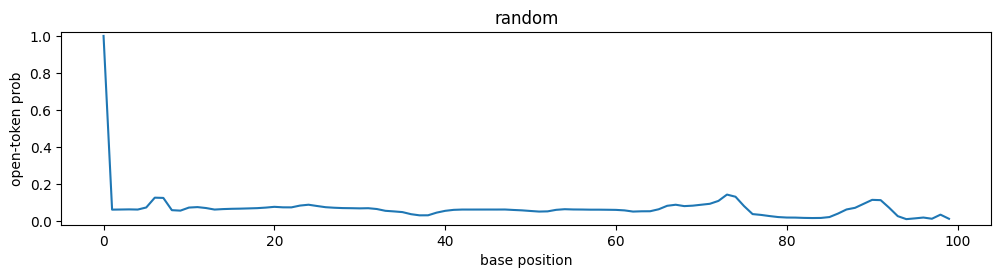

plot_token_probs done
plot_emit_lengths start


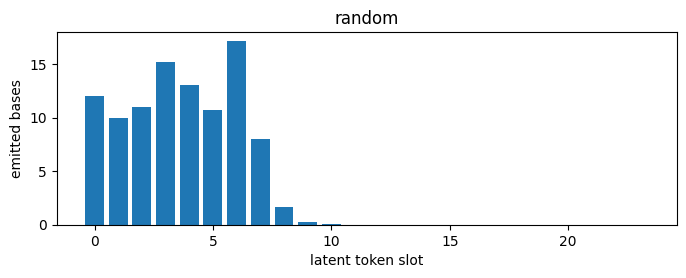

plot_emit_lengths done


In [76]:
idx = 0
plot_token_probs(out, idx, labels[idx])
plot_emit_lengths(out, idx, labels[idx])

## Latent interpolation

Encode two sequences, interpolate their latent tokens and token usages, and decode each midpoint deterministically with argmax.

In [80]:
@torch.no_grad()
def interpolate_sequences(seq_a, seq_b, steps=5):
    print(f'interpolate_sequences: steps={steps}')
    t0 = time.perf_counter()
    target, mask, lengths = make_batch_from_strings([seq_a, seq_b])
    print('tokenizing endpoints...')
    tok = model.tokenize(target, mask)
    z_a, z_b = tok['latents'][0:1], tok['latents'][1:2]
    u_a, u_b = tok['token_usage'][0:1], tok['token_usage'][1:2]
    rows = []
    for i in range(steps):
        alpha = i / (steps - 1)
        print(f'  decode alpha={alpha:.2f}...')
        z = (1 - alpha) * z_a + alpha * z_b
        u = (1 - alpha) * u_a + alpha * u_b
        rendered = model.decode(z, u, args.seq_len)
        pred = rendered['soft_dna'].argmax(dim=-1)[0]
        out_len = int(round(float(rendered['total_len'][0].item())))
        seq = tensor_to_sequence(pred[:max(1, min(args.seq_len, out_len))])
        rows.append((alpha, out_len, float(u.sum().item()), seq))
    print(f'interpolation done in {time.perf_counter() - t0:.2f}s')
    return rows

rows = interpolate_sequences(seqs[0], seqs[1], steps=10)
for alpha, out_len, tok, seq in rows:
    print(f'a={alpha:.2f} len={out_len:3d} tokens={tok:5.2f} {seq[:100]}')


interpolate_sequences: steps=10
make_batch_from_strings: 2 seqs, model max_len=100
lengths: [100, 100]
tokenizing endpoints...
  decode alpha=0.00...
  decode alpha=0.11...
  decode alpha=0.22...
  decode alpha=0.33...
  decode alpha=0.44...
  decode alpha=0.56...
  decode alpha=0.67...
  decode alpha=0.78...
  decode alpha=0.89...
  decode alpha=1.00...
interpolation done in 0.17s
a=0.00 len=100 tokens= 7.07 CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAAACTGGCAGGGCTTTTAGTCGTG
a=0.11 len=100 tokens= 7.06 CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAAACTGGCAGGGCTTTTAGTCGTG
a=0.22 len=100 tokens= 7.06 CCGTTATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAGACTGGCAGGGCTTTTAGTCGTG
a=0.33 len=100 tokens= 7.05 GCGTTATGCCTTTCCCTAACGGGGTTTTTCGAACTCGGGTTGTCGAGCGACGGAATTGGATCAGTTAAATGGCGGAAGACTGGCGGGGCTTTGAGGAGTG
a=0.44 len=100 tokens= 7.05 GCGGTGTGGCGTTCCGTGACGGGGTTTTTCGGAGTCGGGTGGGGGAGCGGGGGGATTGGAGCGGGGGAATG

## Local latent perturbations

This checks whether small latent moves produce small deterministic DNA changes.

In [81]:
@torch.no_grad()
def perturb_sequence(seq, noise_scales=(0.03, 0.1), samples=3):
    print(f'perturb_sequence: {len(seq)} bp, samples={samples}, scales={noise_scales}')
    t0 = time.perf_counter()
    target, mask, lengths = make_batch_from_strings([seq])
    tok = model.tokenize(target, mask)
    base = model.decode(tok['latents'], tok['token_usage'], args.seq_len)
    base_seq = tensor_to_sequence(base['soft_dna'].argmax(dim=-1)[0, :int(lengths[0].item())])
    for scale in noise_scales:
        print(f' scale {scale}:')
        dists = []
        examples = []
        for sample_idx in range(samples):
            print(f'   sample {sample_idx + 1}/{samples}')
            noisy_z = tok['latents'] + torch.randn_like(tok['latents']) * scale
            rendered = model.decode(noisy_z, tok['token_usage'], args.seq_len)
            pred = tensor_to_sequence(rendered['soft_dna'].argmax(dim=-1)[0, :int(lengths[0].item())])
            dists.append(hamming_frac(base_seq, pred))
            examples.append(pred)
        print(f'noise={scale:.3f} mean_hamming={sum(dists)/len(dists):.3f} example={examples[0][:100]}')
    print(f'perturbation done in {time.perf_counter() - t0:.2f}s')

perturb_sequence(seqs[0])


perturb_sequence: 100 bp, samples=3, scales=(0.03, 0.1)
make_batch_from_strings: 1 seqs, model max_len=100
lengths: [100]
 scale 0.03:
   sample 1/3
   sample 2/3
   sample 3/3
noise=0.030 mean_hamming=0.000 example=CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTAGATCAGTTAAATGGCAGAAAACTGGCAGGGCTTTTAGTCGTG
 scale 0.1:
   sample 1/3
   sample 2/3
   sample 3/3
noise=0.100 mean_hamming=0.317 example=CCGTAATGCCTTTCCCTAACAGAGTTTTTCGAACTCGTGTTGTCGAGCGACGGAATTGGATCAGTTAAATGGCAAAAAACTGGCAGGGGTTTTGGGTCGT
perturbation done in 0.11s


## Direct deterministic decode from random latents

This bypasses the encoder. It is rough, but useful for seeing whether decoder-only latents produce stable DNA-like strings.

In [79]:
@torch.no_grad()
def random_decode(token_count=12.0, latent_scale=0.5, n=3):
    print(f'random_decode: token_count={token_count}, latent_scale={latent_scale}, n={n}')
    t0 = time.perf_counter()
    for i in range(n):
        print(f'  sample {i + 1}/{n}')
        z = torch.randn(1, args.max_tokens, args.latent_dim, device=device) * latent_scale
        ids = torch.arange(args.max_tokens, device=device, dtype=torch.float32) + 0.5
        usage = torch.sigmoid((token_count - ids)[None, :] / args.token_usage_temperature)
        rendered = model.decode(z, usage, args.seq_len)
        out_len = int(round(float(rendered['total_len'][0].item())))
        pred = rendered['soft_dna'].argmax(dim=-1)[0, :max(1, min(args.seq_len, out_len))]
        print(f'{i:02d} len={out_len:3d} tokens={usage.sum().item():5.2f} {tensor_to_sequence(pred)}')
    print(f'random_decode done in {time.perf_counter() - t0:.2f}s')

random_decode(token_count=12.0, latent_scale=0.5, n=3)


random_decode: token_count=12.0, latent_scale=0.5, n=3
  sample 1/3
00 len=119 tokens=12.00 CCCCCCCCCGAGGCAAAAAAACCTTCTCCCGGGAAAGGGACCCCCCCCACAAAGAGAAAAAAAACAGACCCTGGCGAGGGGAAAGGGAAAAAAAAAAATT
  sample 2/3
01 len=112 tokens=12.00 GATCCTCGACAGCGAAAAGGCCGCAACCCACAAAAAAACCAAAAAAATGCCGCGGGGGGGGGGGGGAAAAAAAATCCGGCTTTGTACCCCCCCCAAAAAA
  sample 3/3
02 len=111 tokens=12.00 CACCAATAAAAAAACAATAACCCACCCCCGGGCCCCAAACCCGGGGTCGGGTTCCCCTTCTCCCCCCCACGAAAAGAGGGGGGCCGCCTCCCTTTTGGAG
random_decode done in 0.02s
